In [2]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data Loading
df = pd.read_csv('customer-data.csv')

# Summary
print(df.shape)
print(df.dtypes)
print(df.head())
print(df.describe())
print(df.isnull().sum())

(10000, 19)
id                       int64
age                     object
gender                  object
race                    object
driving_experience      object
education               object
income                  object
credit_score           float64
vehicle_ownership         bool
vehicle_year            object
married                   bool
children                  bool
postal_code              int64
annual_mileage         float64
vehicle_type            object
speeding_violations      int64
DUIs                     int64
past_accidents           int64
outcome                   bool
dtype: object
       id    age  gender      race driving_experience    education  \
0  569520    65+  female  majority               0-9y  high school   
1  750365  16-25    male  majority               0-9y         none   
2  199901  16-25  female  majority               0-9y  high school   
3  478866  16-25    male  majority               0-9y   university   
4  731664  26-39    male  majority 

In [3]:
df = df.drop(columns=['race', 'id', 'postal_code'])

# We're dropping race due to ethical considerations
# some states it's actually illegal
# id is unique and therefore not needed.
# postal_code is removed as it doesn't adequately provide us information about insurance claimer's location

outcome
False    6867
True     3133
Name: count, dtype: int64
outcome
False    68.67
True     31.33
Name: proportion, dtype: float64


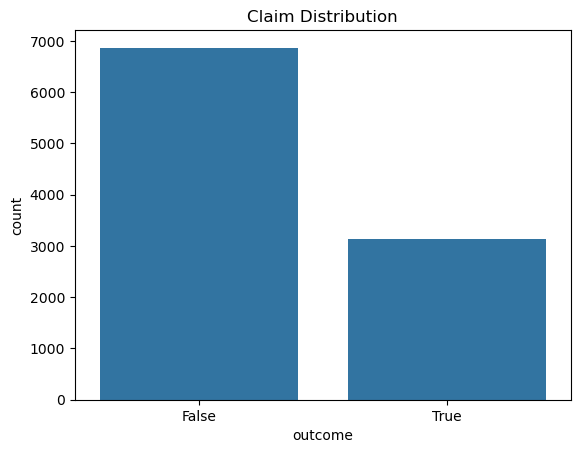

In [4]:
# Claim Distribution

print(df['outcome'].value_counts())
print(df['outcome'].value_counts(normalize=True) * 100)

sns.countplot(x='outcome', data=df)
plt.title('Claim Distribution')
plt.show()

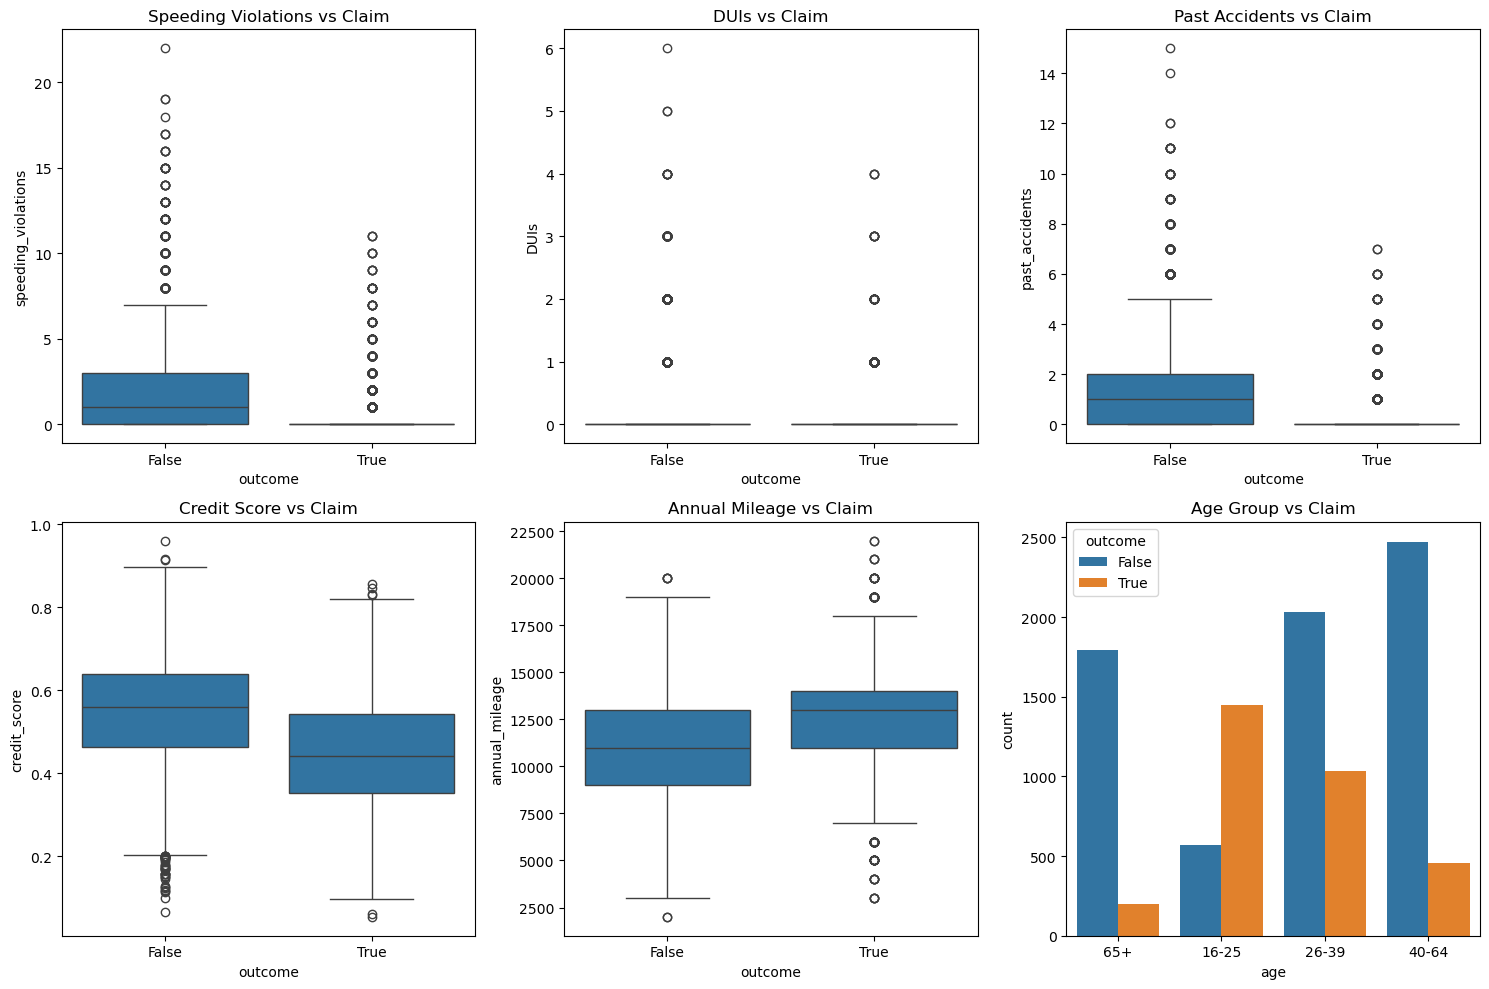

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Driving record features vs outcome
sns.boxplot(x='outcome', y='speeding_violations', data=df, ax=axes[0,0])
axes[0,0].set_title('Speeding Violations vs Claim')

sns.boxplot(x='outcome', y='DUIs', data=df, ax=axes[0,1])
axes[0,1].set_title('DUIs vs Claim')

sns.boxplot(x='outcome', y='past_accidents', data=df, ax=axes[0,2])
axes[0,2].set_title('Past Accidents vs Claim')

sns.boxplot(x='outcome', y='credit_score', data=df, ax=axes[1,0])
axes[1,0].set_title('Credit Score vs Claim')

sns.boxplot(x='outcome', y='annual_mileage', data=df, ax=axes[1,1])
axes[1,1].set_title('Annual Mileage vs Claim')

sns.countplot(x='age', hue='outcome', data=df, ax=axes[1,2])
axes[1,2].set_title('Age Group vs Claim')

plt.tight_layout()
plt.show()

In [6]:
# Numerical summary by outcome
summary = df.groupby('outcome')[['speeding_violations', 'DUIs', 'past_accidents', 
                                  'credit_score', 'annual_mileage']].mean().round(3)
print(summary)

         speeding_violations   DUIs  past_accidents  credit_score  \
outcome                                                             
False                  1.925  0.310           1.404         0.546   
True                   0.514  0.084           0.294         0.450   

         annual_mileage  
outcome                  
False         11342.853  
True          12482.562  


In [9]:
print(f"credit_score Missing: {df['credit_score'].isnull().sum()}")
print(f"annual_mileage Missing: {df['annual_mileage'].isnull().sum()}")
print(f"Total Rows if Dropped: {df.dropna().shape[0]}")
print(f"Rows Lost: {10000 - df.dropna().shape[0]}")
print(f"Percentage Lost: {(10000 - df.dropna().shape[0]) / 10000 * 100:.1f}%")
# 18 percent loss of data is too signifcant

credit_score Missing: 982
annual_mileage Missing: 957
Total Rows if Dropped: 8149
Rows Lost: 1851
Percentage Lost: 18.5%


In [10]:
# Replace missing values with median
df['credit_score'] = df['credit_score'].fillna(df['credit_score'].median())
df['annual_mileage'] = df['annual_mileage'].fillna(df['annual_mileage'].median())

# Verify no more missing values
print(df.isnull().sum())
print(df.shape)

age                    0
gender                 0
driving_experience     0
education              0
income                 0
credit_score           0
vehicle_ownership      0
vehicle_year           0
married                0
children               0
annual_mileage         0
vehicle_type           0
speeding_violations    0
DUIs                   0
past_accidents         0
outcome                0
dtype: int64
(10000, 16)


In [11]:
# We're gonna group in order for ML to classify then cluster
# df is dataframe

# Rank encoding ordered categories (age, experience, education, income)
age_ranking = ['16-25', '26-39', '40-64', '65+']
driving_experience_ranking = ['0-9y', '10-19y', '20-29y', '30y+']
education_ranking = ['none', 'high school', 'university']
income_ranking = ['poverty', 'working class', 'middle class', 'upper class']

df['age'] = pd.Categorical(df['age'], categories=age_ranking, ordered=True).codes
df['driving_experience'] = pd.Categorical(df['driving_experience'], categories=driving_experience_ranking, ordered=True).codes
df['education'] = pd.Categorical(df['education'], categories=education_ranking, ordered=True).codes
df['income'] = pd.Categorical(df['income'], categories=income_ranking, ordered=True).codes

# Binary encoding — Convert any two-class categories to 0/1
df['gender'] = (df['gender'] == 'male').astype(int)
df['vehicle_year'] = (df['vehicle_year'] == 'after 2015').astype(int)
df['vehicle_ownership'] = df['vehicle_ownership'].astype(int)
df['married'] = df['married'].astype(int)
df['children'] = df['children'].astype(int)
df['outcome'] = df['outcome'].astype(int)

# One-hot encoding — vehicle_type has no natural order so we expand it into separate columns
df = pd.get_dummies(df, columns=['vehicle_type'], drop_first=True)
# renamed to vehicle_type_sports car due to two car types: sedan and sports

print(df.head())
print(df.dtypes)

   age  gender  driving_experience  education  income  credit_score  \
0    3       0                   0          1       3      0.629027   
1    0       1                   0          0       0      0.357757   
2    0       0                   0          1       1      0.493146   
3    0       1                   0          2       1      0.206013   
4    1       1                   1          0       1      0.388366   

   vehicle_ownership  vehicle_year  married  children  annual_mileage  \
0                  1             1        0         1         12000.0   
1                  0             0        0         0         16000.0   
2                  1             0        0         0         11000.0   
3                  1             0        0         1         11000.0   
4                  1             0        0         0         12000.0   

   speeding_violations  DUIs  past_accidents  outcome  vehicle_type_sports car  
0                    0     0               0        0

In [12]:
# Fix vehicle_type_sports car dtype
# 0 = sedan
# 1 = sports
df['vehicle_type_sports car'] = df['vehicle_type_sports car'].astype(int)

# Train/test split
from sklearn.model_selection import train_test_split

X = df.drop(columns=['outcome'])
y = df['outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Train outcome balance: {y_train.value_counts(normalize=True).round(3)}")
print(f"Test outcome balance: {y_test.value_counts(normalize=True).round(3)}")

Training set: (8000, 15)
Test set: (2000, 15)
Train outcome balance: outcome
0    0.687
1    0.313
Name: proportion, dtype: float64
Test outcome balance: outcome
0    0.686
1    0.314
Name: proportion, dtype: float64


In [13]:
# scale data because gradient descent becomes more stable
# K-means clustering this would work, but not for Random Forest or MLP
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling done")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")

Scaling done
X_train_scaled shape: (8000, 15)
X_test_scaled shape: (2000, 15)


In [ ]:
# Fine Tuning Time

In [19]:
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

# Logistic Regression Tuning
lr_params = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'liblinear'],
    'max_iter': [100, 200, 500]
}

lr_search = RandomizedSearchCV(
    LogisticRegression(class_weight='balanced', random_state=42),
    lr_params, n_iter=20, cv=5, scoring='roc_auc', random_state=42, n_jobs=-1
)
lr_search.fit(X_train_scaled, y_train)
print(f"Best LR params: {lr_search.best_params_}")
print(f"Best LR ROC-AUC (CV): {lr_search.best_score_:.3f}")

# Random Forest Tuning
rf_params = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    rf_params, n_iter=20, cv=5, scoring='roc_auc', random_state=42, n_jobs=-1
)
rf_search.fit(X_train_scaled, y_train)
print(f"\nBest RF params: {rf_search.best_params_}")
print(f"Best RF ROC-AUC (CV): {rf_search.best_score_:.3f}")

# MLP Tuning
mlp_params = {
    'hidden_layer_sizes': [(64,), (128,), (64, 32), (128, 64), (128, 64, 32)],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate_init': [0.001, 0.01, 0.1],
    'max_iter': [100, 200]
}

mlp_search = RandomizedSearchCV(
    MLPClassifier(early_stopping=True, validation_fraction=0.1, random_state=42),
    mlp_params, n_iter=20, cv=5, scoring='roc_auc', random_state=42, n_jobs=-1
)
mlp_search.fit(X_train_scaled, y_train)
print(f"\nBest MLP params: {mlp_search.best_params_}")
print(f"Best MLP ROC-AUC (CV): {mlp_search.best_score_:.3f}")

Best LR params: {'solver': 'liblinear', 'max_iter': 500, 'C': 10}
Best LR ROC-AUC (CV): 0.902

Best RF params: {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_depth': 10}
Best RF ROC-AUC (CV): 0.897

Best MLP params: {'max_iter': 100, 'learning_rate_init': 0.001, 'hidden_layer_sizes': (64,), 'alpha': 0.0001}
Best MLP ROC-AUC (CV): 0.899


In [35]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report

# Best parameters: C=10, solver=liblinear, max_iter=500
lr_model = LogisticRegression(C=10, solver='liblinear', max_iter=500,
                               class_weight='balanced', random_state=42)
lr_model.fit(X_train_scaled, y_train)

# Predict
lr_preds = lr_model.predict(X_test_scaled)
lr_probs = lr_model.predict_proba(X_test_scaled)[:, 1]

# Evaluate
print("=== Logistic Regression ===")
print(f"Accuracy:  {accuracy_score(y_test, lr_preds):.3f}")
print(f"F1 Score:  {f1_score(y_test, lr_preds):.3f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, lr_probs):.3f}")
print("\nClassification Report:")
print(classification_report(y_test, lr_preds, target_names=['No Claim', 'Claim']))

=== Logistic Regression ===
Accuracy:  0.798
F1 Score:  0.723
ROC-AUC:   0.886

Classification Report:
              precision    recall  f1-score   support

    No Claim       0.91      0.78      0.84      1373
       Claim       0.63      0.84      0.72       627

    accuracy                           0.80      2000
   macro avg       0.77      0.81      0.78      2000
weighted avg       0.83      0.80      0.80      2000



In [36]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier

# Best parameters: n_estimators=200, max_depth=10, min_samples_split=10, min_samples_leaf=2
rf_model = RandomForestClassifier(n_estimators=200, max_depth=10,
                                   min_samples_split=10, min_samples_leaf=2,
                                   class_weight='balanced', random_state=42)
rf_model.fit(X_train_scaled, y_train)

# Predict
rf_preds = rf_model.predict(X_test_scaled)
rf_probs = rf_model.predict_proba(X_test_scaled)[:, 1]

# Evaluate
print("=== Random Forest ===")
print(f"Accuracy:  {accuracy_score(y_test, rf_preds):.3f}")
print(f"F1 Score:  {f1_score(y_test, rf_preds):.3f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, rf_probs):.3f}")
print("\nClassification Report:")
print(classification_report(y_test, rf_preds, target_names=['No Claim', 'Claim']))

=== Random Forest ===
Accuracy:  0.818
F1 Score:  0.734
ROC-AUC:   0.875

Classification Report:
              precision    recall  f1-score   support

    No Claim       0.90      0.83      0.86      1373
       Claim       0.68      0.80      0.73       627

    accuracy                           0.82      2000
   macro avg       0.79      0.81      0.80      2000
weighted avg       0.83      0.82      0.82      2000



In [37]:
# MLP
from sklearn.neural_network import MLPClassifier

# Best parameters: hidden_layer_sizes=(64,), alpha=0.0001, learning_rate_init=0.001
mlp_model = MLPClassifier(hidden_layer_sizes=(64,), alpha=0.0001,
                           learning_rate_init=0.001, max_iter=100,
                           early_stopping=True, validation_fraction=0.1,
                           random_state=42)
mlp_model.fit(X_train_scaled, y_train)

# Predict
mlp_preds = mlp_model.predict(X_test_scaled)
mlp_probs = mlp_model.predict_proba(X_test_scaled)[:, 1]

# Evaluate
print("=== MLP ===")
print(f"Accuracy:  {accuracy_score(y_test, mlp_preds):.3f}")
print(f"F1 Score:  {f1_score(y_test, mlp_preds):.3f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, mlp_probs):.3f}")
print("\nClassification Report:")
print(classification_report(y_test, mlp_preds, target_names=['No Claim', 'Claim']))

=== MLP ===
Accuracy:  0.828
F1 Score:  0.718
ROC-AUC:   0.883

Classification Report:
              precision    recall  f1-score   support

    No Claim       0.87      0.89      0.88      1373
       Claim       0.74      0.70      0.72       627

    accuracy                           0.83      2000
   macro avg       0.80      0.79      0.80      2000
weighted avg       0.83      0.83      0.83      2000



Model                     Accuracy       F1  ROC-AUC
Logistic Regression          0.798    0.723    0.886
Random Forest                0.818    0.734    0.875
MLP                          0.828    0.718    0.883


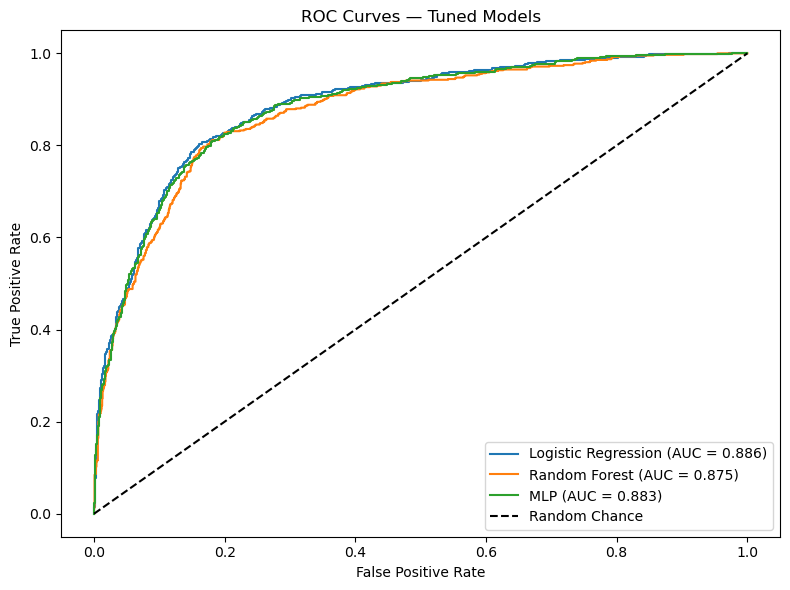

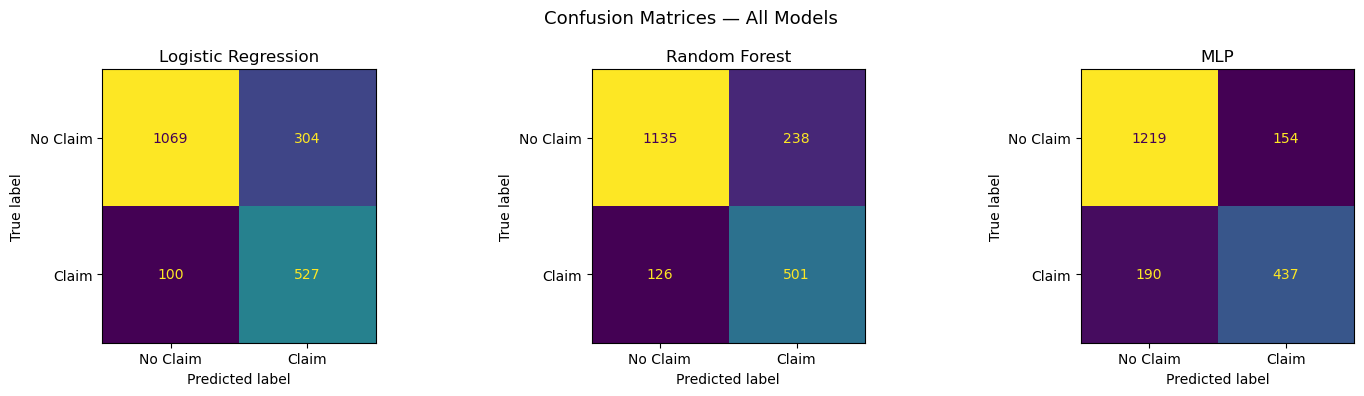

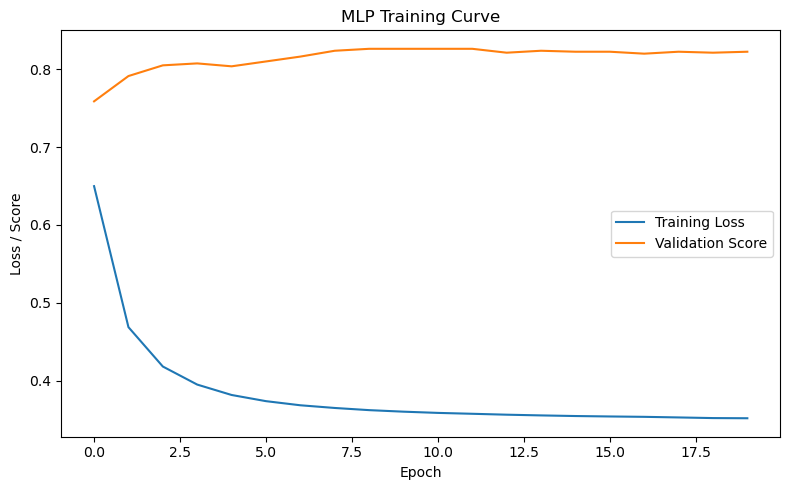

In [38]:
# Total Predictions
tuned_preds_probs = {
    'Logistic Regression': (lr_preds, lr_probs),
    'Random Forest':       (rf_preds, rf_probs),
    'MLP':                 (mlp_preds, mlp_probs)
}

# Summary Table Metric
print("=" * 55)
print(f"{'Model':<25} {'Accuracy':>8} {'F1':>8} {'ROC-AUC':>8}")
print("=" * 55)
for name, (preds, probs) in tuned_preds_probs.items():
    acc = accuracy_score(y_test, preds)
    f1  = f1_score(y_test, preds)
    auc = roc_auc_score(y_test, probs)
    print(f"{name:<25} {acc:>8.3f} {f1:>8.3f} {auc:>8.3f}")
print("=" * 55)

# ROC Curves
plt.figure(figsize=(8, 6))
for name, (preds, probs) in tuned_preds_probs.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Tuned Models')
plt.legend()
plt.tight_layout()
plt.show()

# Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, (preds, probs)) in zip(axes, tuned_preds_probs.items()):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['No Claim', 'Claim']
    )
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(f'{name}')
plt.suptitle('Confusion Matrices — All Models', fontsize=13)
plt.tight_layout()
plt.show()

# MLP Training Curve
plt.figure(figsize=(8, 5))
plt.plot(mlp_model.loss_curve_, label='Training Loss')
if mlp_model.validation_scores_ is not None:
    plt.plot(mlp_model.validation_scores_, label='Validation Score')
plt.xlabel('Epoch')
plt.ylabel('Loss / Score')
plt.title('MLP Training Curve')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Clustering

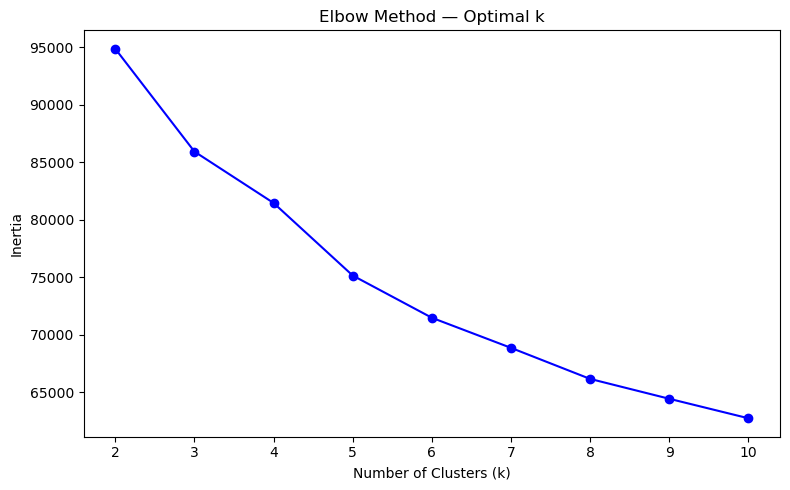

In [22]:
from sklearn.cluster import KMeans

# Use scaled features but drop outcome — clustering is unsupervised
X_cluster = X_train_scaled.copy()

# Elbow method — test k from 2 to 10
inertias = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method — Optimal k')
plt.xticks(k_range)
plt.tight_layout()
plt.show()

In [23]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_cluster)
    score = silhouette_score(X_cluster, labels)
    silhouette_scores.append(score)

for k, score in zip(k_range, silhouette_scores):
    print(f"k={k}: {score:.4f}")

k=2: 0.1891
k=3: 0.1477
k=4: 0.1189
k=5: 0.1309
k=6: 0.1202
k=7: 0.1197
k=8: 0.1170
k=9: 0.1132
k=10: 0.1145


In [24]:
# Fit final K-Means with k=2
kmeans_final = KMeans(n_clusters=2, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_cluster)

# Add cluster labels back to training data
X_train_clustered = X_train.copy()
X_train_clustered['cluster'] = cluster_labels
X_train_clustered['outcome'] = y_train.values

# Check claim rate per cluster
print(X_train_clustered.groupby('cluster')['outcome'].mean().round(3))
print(X_train_clustered.groupby('cluster')['outcome'].count())

cluster
0    0.558
1    0.112
Name: outcome, dtype: float64
cluster
0    3608
1    4392
Name: outcome, dtype: int64


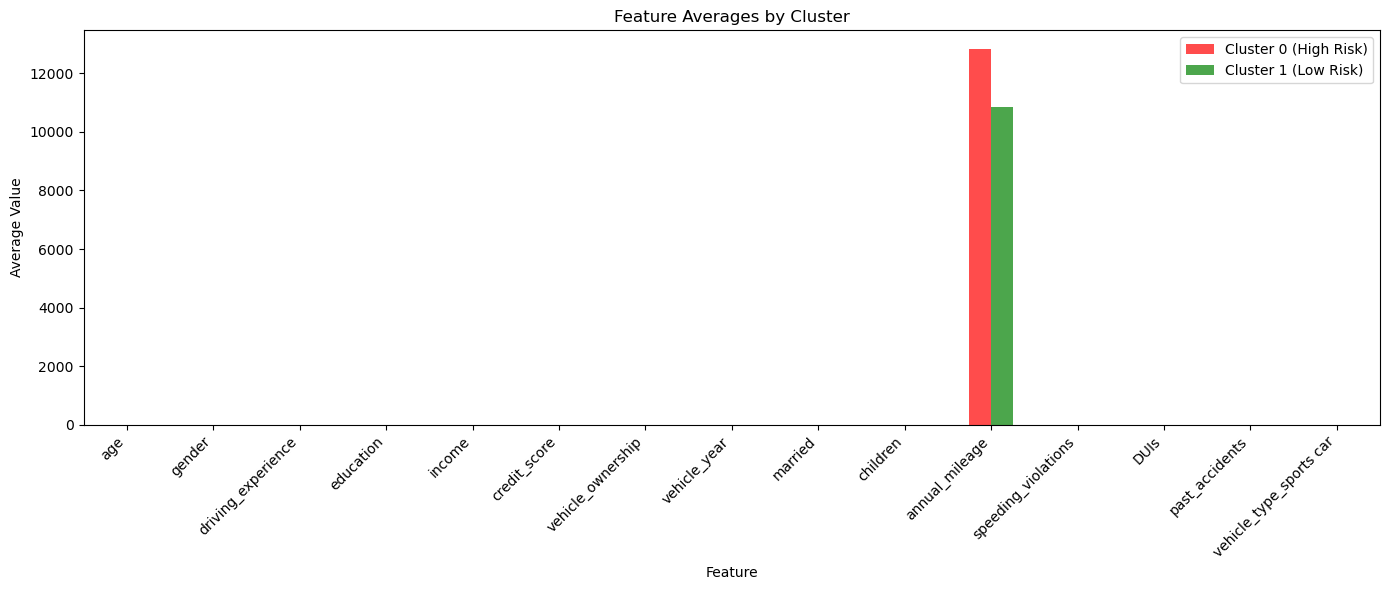

In [25]:
# Feature profile per cluster
cluster_profile = X_train_clustered.groupby('cluster').mean().round(3)

# Plot feature profiles
cluster_profile.drop(columns=['outcome']).T.plot(
    kind='bar', figsize=(14, 6), 
    color=['red', 'green'],
    alpha=0.7
)
plt.title('Feature Averages by Cluster')
plt.xlabel('Feature')
plt.ylabel('Average Value')
plt.xticks(rotation=45, ha='right')
plt.legend(['Cluster 0 (High Risk)', 'Cluster 1 (Low Risk)'])
plt.tight_layout()
plt.show()

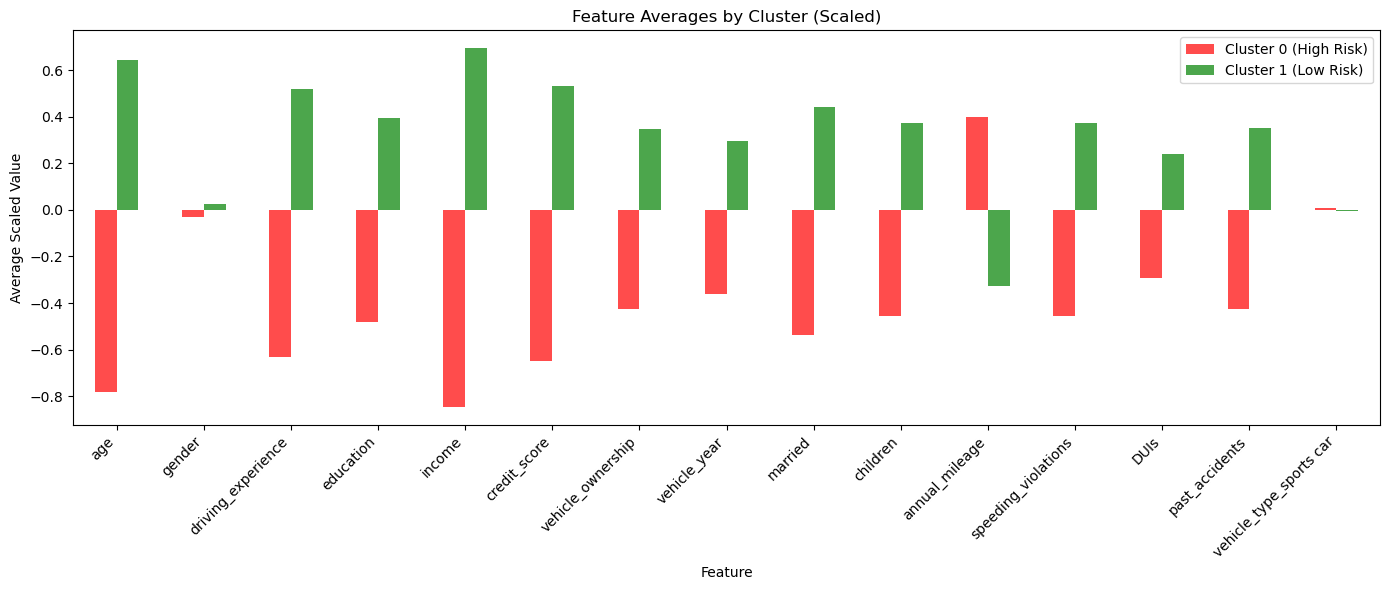

cluster                      0      1
age                     -0.782  0.643
gender                  -0.029  0.024
driving_experience      -0.634  0.521
education               -0.482  0.396
income                  -0.847  0.695
credit_score            -0.648  0.532
vehicle_ownership       -0.424  0.348
vehicle_year            -0.360  0.295
married                 -0.537  0.441
children                -0.455  0.374
annual_mileage           0.399 -0.328
speeding_violations     -0.456  0.374
DUIs                    -0.291  0.239
past_accidents          -0.427  0.351
vehicle_type_sports car  0.007 -0.005


In [27]:
import pandas as pd

# Use scaled data for visualization
X_train_clustered_scaled = pd.DataFrame(
    X_train_scaled, 
    columns=X_train.columns
)
X_train_clustered_scaled['cluster'] = cluster_labels
X_train_clustered_scaled['outcome'] = y_train.values

# Feature profile on scaled data
cluster_profile_scaled = X_train_clustered_scaled.groupby('cluster').mean().round(3)

# Plot
cluster_profile_scaled.drop(columns=['outcome']).T.plot(
    kind='bar', figsize=(14, 6),
    color=['red', 'green'],
    alpha=0.7
)
plt.title('Feature Averages by Cluster (Scaled)')
plt.xlabel('Feature')
plt.ylabel('Average Scaled Value')
plt.xticks(rotation=45, ha='right')
plt.legend(['Cluster 0 (High Risk)', 'Cluster 1 (Low Risk)'])
plt.tight_layout()
plt.show()

# Print the actual numbers
print(cluster_profile_scaled.drop(columns=['outcome']).T.to_string())

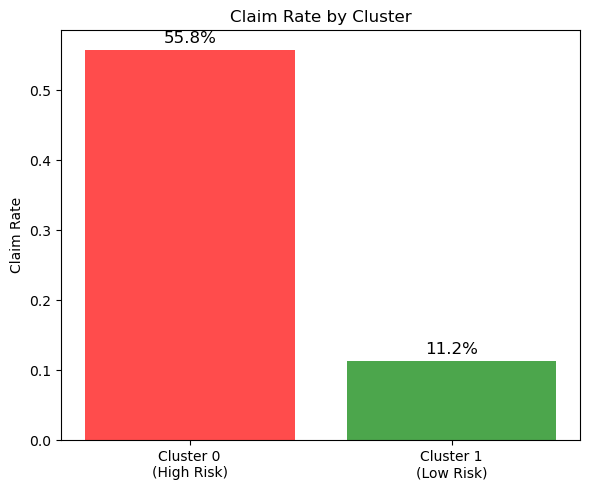

In [28]:
# Cluster vs claim rate bar chart
cluster_claim_rate = X_train_clustered_scaled.groupby('cluster')['outcome'].mean()

plt.figure(figsize=(6, 5))
bars = plt.bar(['Cluster 0\n(High Risk)', 'Cluster 1\n(Low Risk)'], 
               cluster_claim_rate.values,
               color=['red', 'green'], alpha=0.7)
plt.ylabel('Claim Rate')
plt.title('Claim Rate by Cluster')
for bar, rate in zip(bars, cluster_claim_rate.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{rate:.1%}', ha='center', fontsize=12)
plt.tight_layout()
plt.show()

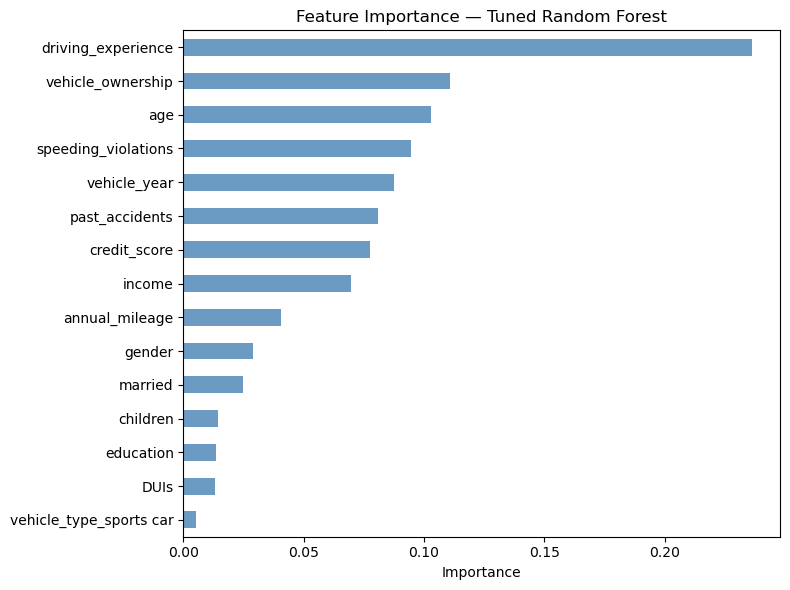

In [29]:
# Feature importance from tuned Random Forest
importances = rf_tuned.feature_importances_
feature_names = X_train.columns

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=True)

plt.figure(figsize=(8, 6))
feat_imp.plot(kind='barh', color='steelblue', alpha=0.8)
plt.title('Feature Importance — Tuned Random Forest')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

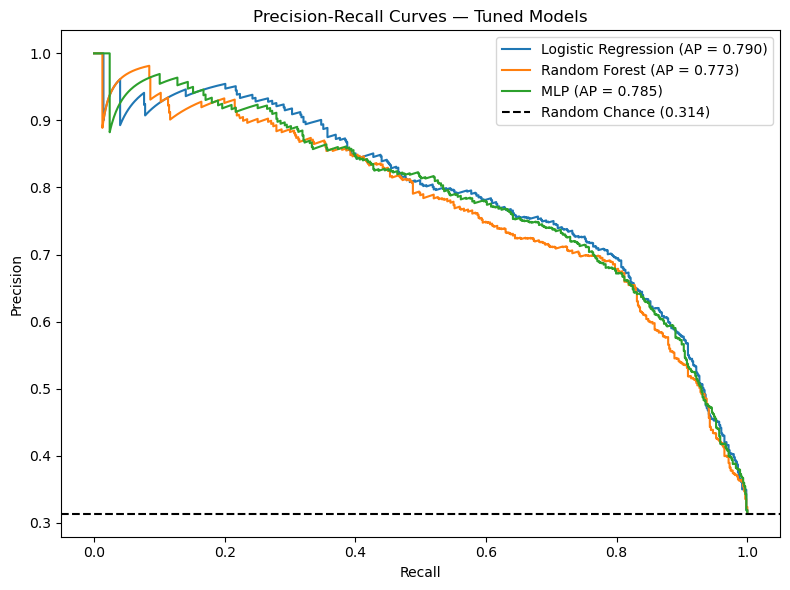

In [30]:
# Precision vs Recall Curve
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(8, 6))

for name, (preds, probs) in tuned_preds_probs.items():
    precision, recall, _ = precision_recall_curve(y_test, probs)
    ap = average_precision_score(y_test, probs)
    plt.plot(recall, precision, label=f'{name} (AP = {ap:.3f})')

# Baseline — random classifier
baseline = y_test.mean()
plt.axhline(y=baseline, color='k', linestyle='--', label=f'Random Chance ({baseline:.3f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves — Tuned Models')
plt.legend()
plt.tight_layout()
plt.show()

In [31]:
# Add cluster label as a feature to classification
X_train_with_cluster = X_train_scaled.copy()
X_test_with_cluster = X_test_scaled.copy()

# Get cluster labels for test set too
test_cluster_labels = kmeans_final.predict(X_test_scaled)

import numpy as np
X_train_with_cluster = np.column_stack([X_train_scaled, cluster_labels])
X_test_with_cluster = np.column_stack([X_test_scaled, test_cluster_labels])

# Retrain best model (Logistic Regression) with cluster feature
lr_cluster = LogisticRegression(C=10, solver='liblinear', 
                                 class_weight='balanced', 
                                 max_iter=500, random_state=42)
lr_cluster.fit(X_train_with_cluster, y_train)

preds_cluster = lr_cluster.predict(X_test_with_cluster)
probs_cluster = lr_cluster.predict_proba(X_test_with_cluster)[:, 1]

print("=== Logistic Regression WITH Cluster Feature ===")
print(f"Accuracy:  {accuracy_score(y_test, preds_cluster):.3f}")
print(f"F1 Score:  {f1_score(y_test, preds_cluster):.3f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, probs_cluster):.3f}")
print(f"Avg Precision: {average_precision_score(y_test, probs_cluster):.3f}")

print("\n=== Logistic Regression WITHOUT Cluster Feature ===")
print(f"Accuracy:  0.798")
print(f"F1 Score:  0.723")
print(f"ROC-AUC:   0.886")
print(f"Avg Precision: 0.790")

=== Logistic Regression WITH Cluster Feature ===
Accuracy:  0.799
F1 Score:  0.724
ROC-AUC:   0.886
Avg Precision: 0.790

=== Logistic Regression WITHOUT Cluster Feature ===
Accuracy:  0.798
F1 Score:  0.723
ROC-AUC:   0.886
Avg Precision: 0.790


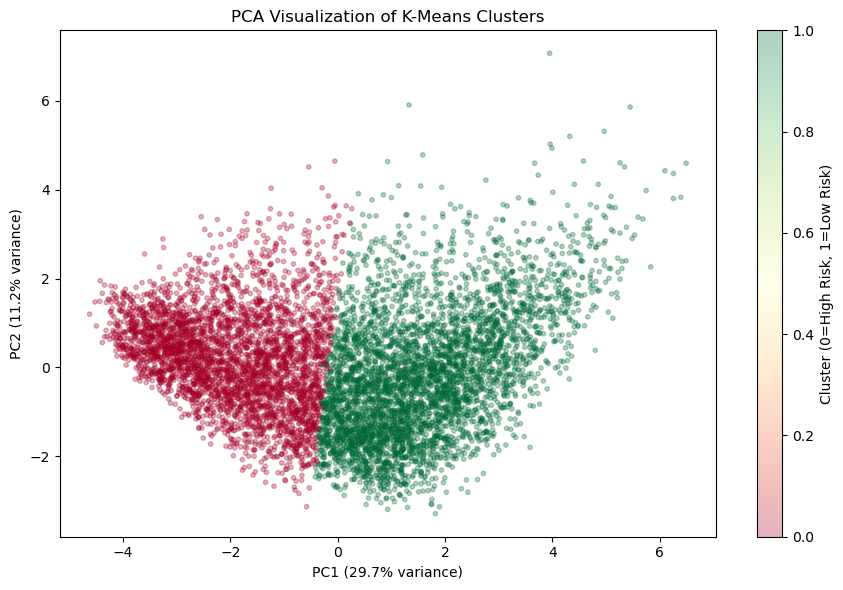

Total variance explained: 40.9%


In [33]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_train_scaled)

plt.figure(figsize=(9, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], 
                      c=cluster_labels, 
                      cmap='RdYlGn',
                      alpha=0.3, s=10)
plt.colorbar(scatter, label='Cluster (0=High Risk, 1=Low Risk)')
plt.title('PCA Visualization of K-Means Clusters')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.tight_layout()
plt.show()

print(f"Total variance explained: {sum(pca.explained_variance_ratio_):.1%}")